In [1]:
from jacobian import get_jacobian

In [2]:
import submitDACCAD
from ReservoirRun import Reservoir
import numpy as np
from numpy import linalg as LA
import os
from datetime import datetime
from evolver import DaccadBioneatMut
from evolver import DaccadBioneatMut_smaller
from qdpy.containers import *
from individual import *

In [3]:
def calc_eig_of_jacobian(myarray):
    config = {'daccad': {'path':'../../daccad'}}
    scales = [1000.0, 200.0]
    npeaks = 1
    nNodes = 2
    scaling = [scales[0]]*nNodes+[scales[1]]*(nNodes*nNodes*(nNodes+1))
    jikeiretu = submitDACCAD.submitPENSystem_input(myarray, nNodes = nNodes, executablePath=config['daccad']['path'],
                                                     configFile = os.path.abspath(os.getcwd())+"/" + '../daccadConf.conf', 
                                                     jsonFileName=os.path.abspath(os.getcwd())+"/"+"."+"/"+datetime.now().isoformat(timespec='microseconds')+".json",
                                                     configFile_input = os.path.abspath(os.getcwd())+"/" + "../config_mc.json"
                                                     ).decode('ascii')
    jikeiretu_arr = [[float(a) for a in line.split(',')] for line in jikeiretu.split('\n')[3003:-1]]
    # f = pd.DataFrame(arr)
    print("jikeiretu : ")
    print(jikeiretu_arr)

    matrix = np.zeros([7, 7])
    matrix = get_jacobian(myarray, jikeiretu_arr[-1])
    print("matrix : ")
    print(matrix)

    w, v = LA.eig(matrix)
    print("w, v : ", w, v)

In [4]:
myarray = np.array([1.0, 10.0, 0, 0.5, 0., 0, 0, 0., 0., 0, 0, 0., 0., 0.])
calc_eig_of_jacobian(myarray)

jikeiretu : 
[[1.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0], [0.4627492185949137, 0.5449035240066452, 0.4122024536125419, 0.003308770104696758, 0.023825182233844833, 0.00968721027569418, 0.05097638377322241], [0.21605628248135925, 0.4031195758146113, 0.391581438042341, 0.0017684786821059986, 0.01806374259787868, 0.014438127437045912, 0.07414821324062842], [0.10150658274132625, 0.35982461793357334, 0.38340671265401466, 0.0011086611760989626, 0.014898234053916527, 0.01646737414484074, 0.08411901797112922], [0.04806411558794598, 0.34951496447340485, 0.3797010218501481, 0.0008068425874002542, 0.013815390312802678, 0.017346710699517685, 0.08833003455013139], [0.023077411318320192, 0.3491198203696718, 0.3781344135933682, 0.000668863441984798, 0.013559697587978127, 0.017672431371297766, 0.08996459400537116], [0.0113826112668429, 0.3505972472273407, 0.37767794445129665, 0.0006001469677332939, 0.013560295477772401, 0.01777538255791366, 0.0903862305452842], [0.005905012639132948, 0.3515722285787711, 0.377

In [5]:
myarray = np.array([1.0, 10.0, 0, 50, 0., 0, 0, 0., 0., 0, 0, 0., 0., 0.])
calc_eig_of_jacobian(myarray)

jikeiretu : 
[[1.0, 1.0, 50.0, 0.0, 0.0, 0.0, 0.0], [0.0007190603440667225, 0.5155819577100246, 47.31162036316365, 0.005277402744033913, 1.7545723540765379, 0.15269058238639083, 0.7758392976293915], [0.0006800044051898274, 0.7929275660595859, 46.01964686419339, 0.005132368418133727, 3.0469726228645015, 0.15271164776251056, 0.7755364967614468], [0.0006791928645127968, 1.0483171118903114, 44.88758692924487, 0.005098617333219414, 4.179494130982162, 0.15266703277558594, 0.7751532896641552], [0.0006784483802439903, 1.2813835155129225, 43.89992356488246, 0.005068082147482909, 5.167618354862718, 0.15262084555285663, 0.774769152554434], [0.0006777491940615448, 1.4923410731800748, 43.04159467561538, 0.005041120694702771, 6.02640742672633, 0.15256992834322955, 0.774386848620308], [0.0006770926002986252, 1.681724583295199, 42.29815590228406, 0.0050170415920659335, 6.770305757171531, 0.15251645064408856, 0.7740048483081894], [0.0006764893386880795, 1.8504163605705868, 41.65608799345941, 0.00499497

In [6]:
eigenvalues = []
mc_lst = []

grid = Grid(shape=(10,10), max_items_per_bin=1, fitness_domain=((0., 1.),), features_domain=((0., 1.), (0., 1.)))

for _ in range(100):
    evo = DaccadBioneatMut_smaller(grid, 10, [0.0,200.0], nb_nodes_domain=[2,2])
    indiv = evo.ask()
    print("indiv: ", indiv)
    
    daccadIndiv = indiv
    config = {'daccad': {'path':'../../daccad'}}
    scales = [1000.0, 200.0]
    npeaks = 1
    nNodes = daccadIndiv.nb_nodes
    print("nNodes : ", nNodes)
    scaling = [scales[0]]*nNodes+[scales[1]]*(nNodes*nNodes*(nNodes+1))
    myarray = np.array(scaling)*np.array(daccadIndiv)
    jikeiretu = submitDACCAD.submitPENSystem_input(myarray, nNodes = nNodes, executablePath=config['daccad']['path'],
                                                 configFile = os.path.abspath(os.getcwd())+"/" + '../daccadConf.conf', 
                                                 jsonFileName=os.path.abspath(os.getcwd())+"/"+"."+"/"+datetime.now().isoformat(timespec='microseconds')+".json",
                                                 configFile_input = os.path.abspath(os.getcwd())+"/" + "../config_mc.json"
                                                 ).decode('ascii')
    jikeiretu_arr = [[float(a) for a in line.split(',')] for line in jikeiretu.split('\n')[3003:-1]]
    # f = pd.DataFrame(arr)
    # print("jikeiretu : ")
    # print(jikeiretu_arr)

    matrix = np.zeros([7, 7])
    matrix = get_jacobian(myarray, jikeiretu_arr[-1])
    w, v = LA.eig(matrix)
    
    mc = 0
    k_max = 10
    for k in range(1, k_max + 1):
        Reservoir_mc = Reservoir(ind=myarray, nNodes=nNodes, result=jikeiretu, delay=k)
        data = Reservoir_mc.get_data()
        X, Y = Reservoir_mc.run(data)
        mc_k = Reservoir_mc.get_MCk(data, Y)
        mc += mc_k
    print(mc)
    eigenvalues.append(np.mean([np.linalg.norm(val) for val in w]))
    mc_lst.append(mc)

choice :  1
indiv:  DaccadIndividual([0.01, 0.01, 0.0, 0.025, 0.0, 68.46241391948043, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
9.046201123113057
choice :  2
choice :  0
indiv:  DaccadIndividual([0.009948705524172053, 0.012308196743020364, 0.0, 0.021629181124835875, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
8.715946147995707
choice :  0
indiv:  DaccadIndividual([0.007187453011967523, 0.0051, 0.0, 0.024710321553245075, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
8.596328919108366
choice :  0
indiv:  DaccadIndividual([0.01, 0.010528715179538592, 0.0, 0.039284354418440144, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
8.84242181644183
choice :  1
indiv:  DaccadIndividual([0.01, 0.01, 93.08163685340524, 0.025, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
0.033024505904435356
choice :  0
indiv:  DaccadIndividual([0.0051, 0.024362094116080226, 0.0, 0.01063849737250066, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

8.476004078415254
choice :  1
indiv:  DaccadIndividual([0.01, 0.01, 0.0, 0.025, 159.83565053924391, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
0.26805546124706964
choice :  1
indiv:  DaccadIndividual([0.01, 0.01, 0.0, 0.025, 0.0, 174.02234653968517, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
9.49120620169015
choice :  1
indiv:  DaccadIndividual([0.01, 0.01, 0.0, 0.025, 0.0, 103.1323600447821, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
8.975267483735117
choice :  2
choice :  0
indiv:  DaccadIndividual([0.015331835322473801, 0.010093737762385348, 0.0, 0.0051, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
9.217468796449499
choice :  0
indiv:  DaccadIndividual([0.015065894997667561, 0.01386052916459427, 0.0, 0.0193475632779288, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
8.999732642866554
choice :  2
choice :  2
choice :  2
choice :  1
indiv:  DaccadIndividual([0.01, 0.01, 0.0, 0.025, 110.68151831181837, 0.0, 0.0, 0.0, 

9.069015654749919
choice :  1
indiv:  DaccadIndividual([0.01, 0.01, 0.0, 0.025, 115.03392699893615, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
0.2376687839689937
choice :  0
indiv:  DaccadIndividual([0.012083744831515761, 0.023728272432590375, 0.0, 0.018419539819233, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
8.950652514054074
choice :  0
indiv:  DaccadIndividual([0.01, 0.01, 0.0, 0.025, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
8.672211767563274
choice :  1
indiv:  DaccadIndividual([0.01, 0.01, 0.0, 0.025, 0.0, 103.17741664069314, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
9.296749548727574
choice :  0
indiv:  DaccadIndividual([0.01, 0.009493439911658026, 0.0, 0.04386467767225799, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
8.161766236234312


In [7]:
eigenvalues

[11.31581090299493,
 4.308797589836702,
 4.200193980572555,
 4.934246389113604,
 8.255939212655907,
 3.8497464003366555,
 3.540438865037177,
 4.856989829164775,
 3.9443137017774177,
 10.998883825965294,
 7.840180964853096,
 8.14196038711246,
 7.962772060198165,
 4.221253092855642,
 4.237948910067009,
 10.971724196148285,
 4.457259900957561,
 8.185824948728515,
 11.21774663398487,
 3.5209351274535683,
 7.867923498907307,
 4.056985855278772,
 4.309300600588396,
 7.961960412875586,
 5.131009271649284,
 8.151288358570786,
 4.387322909311007,
 5.102206213138041,
 5.639543513985162,
 10.953184046255435,
 3.751753109372103,
 4.222708597193791,
 4.537406763048183,
 8.206865223587792,
 5.439919655451407,
 11.229531833981174,
 11.168655357776379,
 4.356071829960816,
 3.9891730877337683,
 5.58053113046612,
 3.30257036017376,
 4.345774314918006,
 5.382190693739964,
 8.19824986604902,
 4.71350154794672,
 7.829375211069592,
 3.626047000773031,
 4.932852311228676,
 7.952967383938258,
 11.039910194891

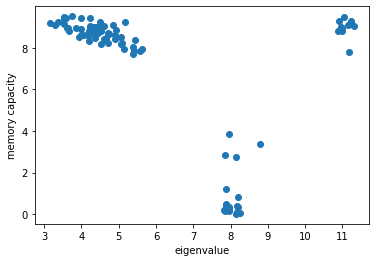

In [8]:
import matplotlib.pyplot as plt
plt.xlabel("eigenvalue")
plt.ylabel("memory capacity")
plt.scatter(eigenvalues, mc_lst)